In [22]:
# Data Science Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import defaultdict
from scipy import stats
import numpy as np

# Pre-Modeling Tasks

from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import LabelEncoder           
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA


# Modeling

# from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation and comparision of all the models

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, confusion_matrix, precision_recall_fscore_support
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve


In [1]:
import pandas as pd

In [2]:
# Loading Data CSV :

df = pd.read_csv("//kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv")

In [3]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.isnull()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False


In [7]:
description_df = df.describe().T
description_df

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Total number of patients :

Outcome Statuts:

Outcome
0    500
1    268
Name: count, dtype: int64

Percentage:

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


<Axes: title={'center': 'Diabetes Outcome'}, xlabel='Outcome'>

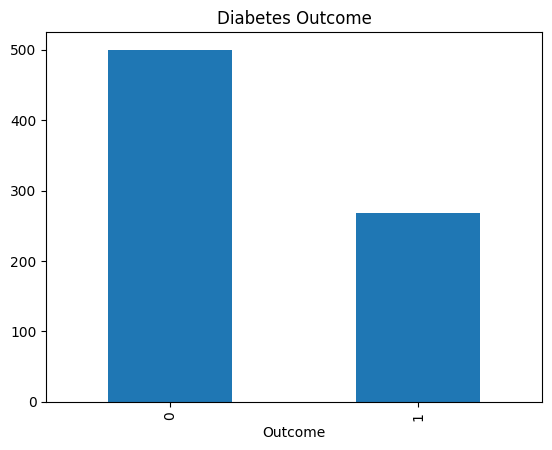

In [20]:
# Number Of diabetic and Non-diabetic Patients :
print ("Total number of patients :"), df.shape[0], ", ",
print("\nOutcome Statuts:\n")
print(df["Outcome"].value_counts())
print("\nPercentage:\n")
print(df["Outcome"].value_counts(normalize=True) *100)

# Bar chart
df["Outcome"].value_counts().plot.bar(title="Diabetes Outcome")

# Correlation Matrix



In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

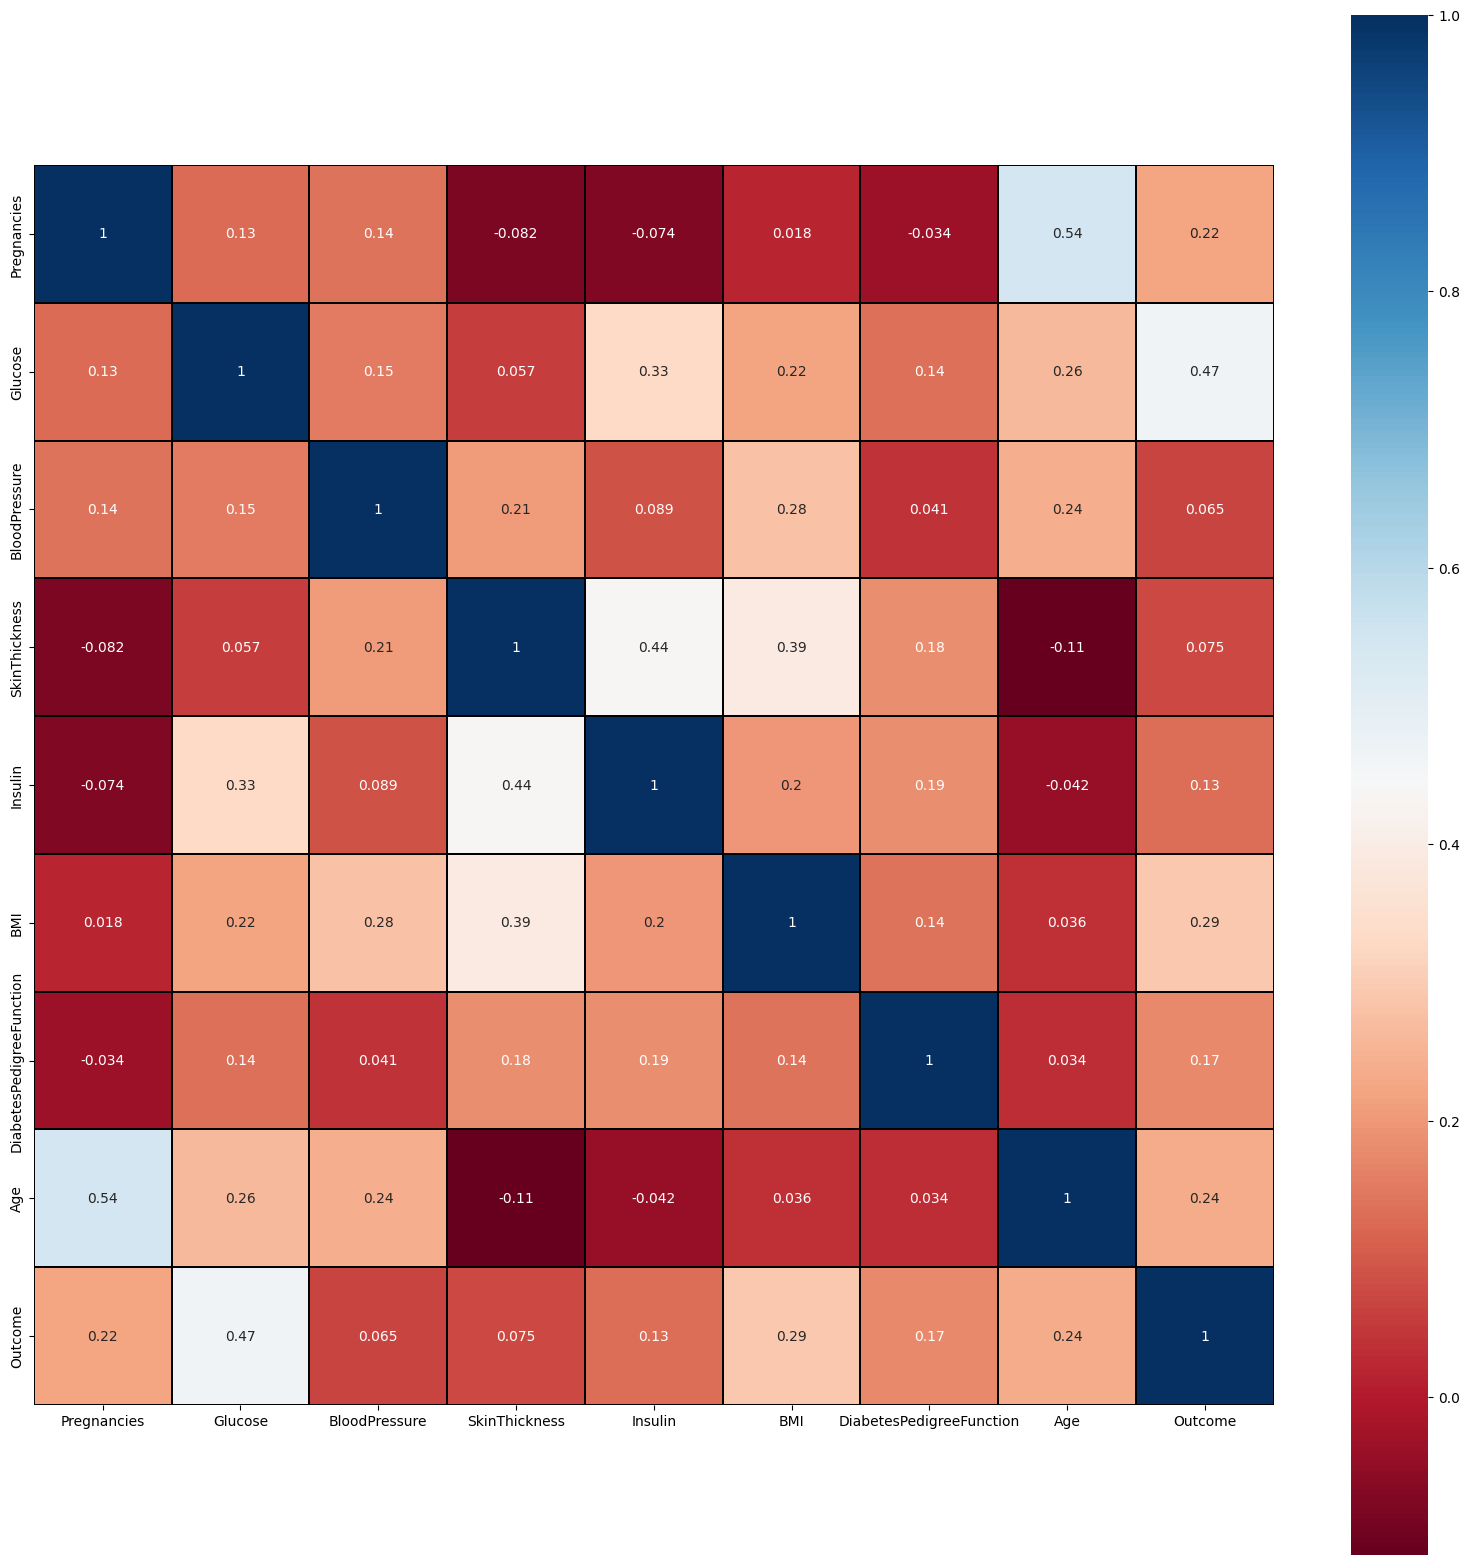

In [25]:
# Correlation matrix
corrMatrix = df.corr()
fig, ax = plt.subplots(figsize=(20,20))
sns.heatmap(corrMatrix, annot=True, linewidth=0.01, square=True, cmap="RdBu", linecolor="black")
plt.show()

In [26]:
from imblearn.over_sampling import RandomOverSampler
import numpy as np

In [28]:
my_data = df 
X = my_data.drop('Outcome', axis=1).values
y = my_data['Outcome'].values

# Oversampling
ros = RandomOverSampler(random_state=0)
X_resampled, y_resampled = ros.fit_resample(X, y)

print("X_resampled = ", X_resampled.shape, "y_resampled = ", y_resampled.shape)
print("Labels : ", np.unique(y_resampled))
print("Nbr of 0 : ", np.count_nonzero(y_resampled == 0))
print("Nbr of 1 : ", np.count_nonzero(y_resampled == 1))

X_resampled =  (1000, 8) y_resampled =  (1000,)
Labels :  [0 1]
Nbr of 0 :  500
Nbr of 1 :  500


 # Deuxiéme Partie de K-FOLD CROSS VALIDATION

In [29]:
from collections import defaultdict

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier

In [33]:
# Define the models
models = {
    'Logistic Regression': LogisticRegression(C=1.0, solver='liblinear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, criterion='entropy', random_state=42),
    #'SVM (poly)': SVC(kernel='poly', degree=3, C=1.0, probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, eval_metric='mlogloss', random_state=42),
    #'LightGBM': LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    #'MLP Neural Network': MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', solver='adam', max_iter=1000, random_state=42)
}

# Store results
results = defaultdict(list)

In [42]:
from imblearn.over_sampling import RandomOverSampler

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier

In [45]:
import numpy as np
from collections import defaultdict
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [46]:
# Initialisation du stockage des résultats
results = defaultdict(list)
best_fold_data = {}  # Pour stocker y_true et y_pred du meilleur fold pour chaque modèle

# 5-fold Stratified K-Fold Cross Validation
n_splits = 5
skf = StratifiedKFold(n_splits = n_splits, shuffle=True, random_state=42)


N_COMPONENTS = 0.70 

for model_name, model in models.items():
    print(f"--- {model_name} (avec PCA) ---")
    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    confidence_intervals = []
    best_accuracy = -1
    best_y_true_fold = None
    best_y_pred_fold = None

    for fold, (train_index, val_index) in enumerate(skf.split(X_resampled, y_resampled)):
        X_train, X_val = X_resampled[train_index], X_resampled[val_index]
        y_train, y_val = y_resampled[train_index], y_resampled[val_index]

        # 1. Standardisation 
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        # 2. Application de la PCA sur les données entraînées uniquement
        pca = PCA(n_components=N_COMPONENTS, random_state=42)
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_val_pca = pca.transform(X_val_scaled)

        # 3. Entraînement et Prédiction sur les composantes PCA
        model.fit(X_train_pca, y_train)
        y_pred = model.predict(X_val_pca)

        # Calcul des métriques
        accuracy = accuracy_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred, zero_division=0)
        recall = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)

        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)

        # Intervalle de confiance pour l'Accuracy
        n = len(y_val)
        mean_accuracy = accuracy
        std_err = np.std(y_pred == y_val) / np.sqrt(n)
        alpha = 0.05  # 95%
        h = std_err * stats.t.ppf((1 + (1 - alpha)) / 2, n - 1)
        confidence_intervals.append((mean_accuracy - h, mean_accuracy + h))

        print(f"Fold {fold+1}: Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

        # Sauvegarde du meilleur fold
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_y_true_fold = y_val
            best_y_pred_fold = y_pred

    avg_accuracy = np.mean(accuracy_scores)
    avg_precision = np.mean(precision_scores)
    avg_recall = np.mean(recall_scores)
    avg_f1 = np.mean(f1_scores)
    avg_confidence_interval = np.mean(confidence_intervals, axis=0)

    # Stockage des résultats globaux
    results['Algorithm'].append(model_name)
    results['Accuracy'].append(avg_accuracy)
    results['Precision'].append(avg_precision)
    results['Recall'].append(avg_recall)
    results['F1 Score'].append(avg_f1)
    results['Confidence Interval (Accuracy)'].append(f"{avg_confidence_interval[0]:.4f} - {avg_confidence_interval[1]:.4f}")

    # Données du meilleur fold
    best_fold_data[model_name] = {'y_true': best_y_true_fold, 'y_pred': best_y_pred_fold}

    # Calcul de la p-value
    baseline_accuracy = 0.05
    t_statistic, p_value = stats.ttest_1samp(accuracy_scores, baseline_accuracy)
    print(f"Average Accuracy: {avg_accuracy:.4f}")
    print(f"95% Confidence Interval (Accuracy): {avg_confidence_interval[0]:.4f} - {avg_confidence_interval[1]:.4f}")
    print(f"P-value (vs. baseline accuracy of {baseline_accuracy:.2f}): {p_value:.4f}")
    print("\n")

--- Logistic Regression (avec PCA) ---
Fold 1: Accuracy=0.7200, Precision=0.7245, Recall=0.7100, F1=0.7172
Fold 2: Accuracy=0.7450, Precision=0.7753, Recall=0.6900, F1=0.7302
Fold 3: Accuracy=0.6700, Precision=0.6809, Recall=0.6400, F1=0.6598
Fold 4: Accuracy=0.7250, Precision=0.7143, Recall=0.7500, F1=0.7317
Fold 5: Accuracy=0.6850, Precision=0.7229, Recall=0.6000, F1=0.6557
Average Accuracy: 0.7090
95% Confidence Interval (Accuracy): 0.6458 - 0.7722
P-value (vs. baseline accuracy of 0.05): 0.0000


--- Random Forest (avec PCA) ---
Fold 1: Accuracy=0.7800, Precision=0.7456, Recall=0.8500, F1=0.7944
Fold 2: Accuracy=0.8800, Precision=0.8455, Recall=0.9300, F1=0.8857
Fold 3: Accuracy=0.7900, Precision=0.7544, Recall=0.8600, F1=0.8037
Fold 4: Accuracy=0.8200, Precision=0.7667, Recall=0.9200, F1=0.8364
Fold 5: Accuracy=0.7850, Precision=0.7478, Recall=0.8600, F1=0.8000
Average Accuracy: 0.8110
95% Confidence Interval (Accuracy): 0.7569 - 0.8651
P-value (vs. baseline accuracy of 0.05): 0.0

             Algorithm  Accuracy  Precision  Recall  F1 Score  \
0  Logistic Regression     0.709   0.723560   0.678  0.698914   
1        Random Forest     0.811   0.771989   0.884  0.824042   
2        Decision Tree     0.772   0.731872   0.858  0.789652   
3    Gradient Boosting     0.803   0.775682   0.854  0.812839   
4              XGBoost     0.787   0.767010   0.826  0.795262   

  Confidence Interval (Accuracy)  
0                0.6458 - 0.7722  
1                0.7569 - 0.8651  
2                0.7138 - 0.8302  
3                0.7478 - 0.8582  
4                0.7301 - 0.8439  


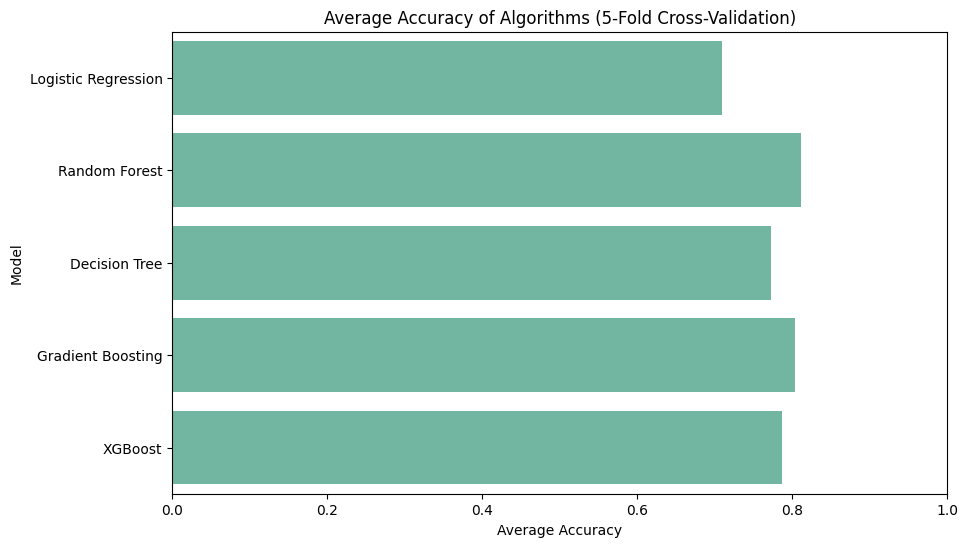

In [48]:
# Create a DataFrame for results visualization
data_frame = pd.DataFrame(results)
print(data_frame)

# Barplot of average accuracy
sns.set_palette("Set2")
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Algorithm', data=data_frame)
plt.title('Average Accuracy of Algorithms (5-Fold Cross-Validation)')
plt.xlabel('Average Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)
#plt.tight_layout()
plt.show()

In [49]:
# Function to display metrics and confusion matrix
def display_metrics_and_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
    labels = ['Diabetes', 'No Diabetes']
    Columns = ['Predicted_Diabetes', 'Predicted_No Diabetes']
    df_cm = pd.DataFrame(cm, index=labels, columns=Columns)

    print(f"=== {model_name} (Best Fold) ===")
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names = labels))
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

    plt.figure(figsize=(4, 3))
    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Set2')
    plt.title(f"Confusion Matrix - {model_name} (Best Fold)")
    plt.ylabel('Actuel')
    plt.xlabel('Predicté')
    plt.tight_layout()
    plt.show()

In [56]:
from sklearn.metrics import confusion_matrix, classification_report

=== Logistic Regression (Best Fold) ===
Classification Report:
               precision    recall  f1-score   support

    Diabetes       0.72      0.80      0.76       100
 No Diabetes       0.78      0.69      0.73       100

    accuracy                           0.74       200
   macro avg       0.75      0.74      0.74       200
weighted avg       0.75      0.74      0.74       200

Accuracy: 0.745
Precision: 0.7752808988764045
Recall: 0.69
F1 Score: 0.7301587301587301


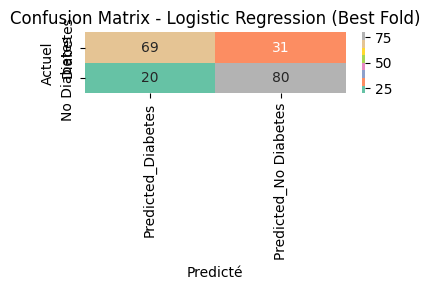

=== Random Forest (Best Fold) ===
Classification Report:
               precision    recall  f1-score   support

    Diabetes       0.92      0.83      0.87       100
 No Diabetes       0.85      0.93      0.89       100

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200

Accuracy: 0.88
Precision: 0.8454545454545455
Recall: 0.93
F1 Score: 0.8857142857142857


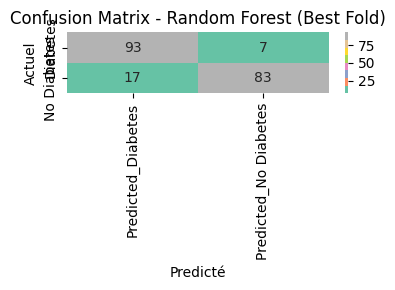

=== Decision Tree (Best Fold) ===
Classification Report:
               precision    recall  f1-score   support

    Diabetes       0.87      0.73      0.79       100
 No Diabetes       0.77      0.89      0.82       100

    accuracy                           0.81       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.82      0.81      0.81       200

Accuracy: 0.81
Precision: 0.7672413793103449
Recall: 0.89
F1 Score: 0.8240740740740741


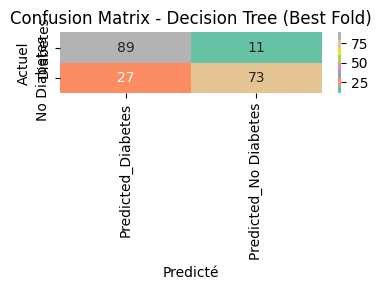

=== Gradient Boosting (Best Fold) ===
Classification Report:
               precision    recall  f1-score   support

    Diabetes       0.88      0.83      0.86       100
 No Diabetes       0.84      0.89      0.86       100

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200

Accuracy: 0.86
Precision: 0.839622641509434
Recall: 0.89
F1 Score: 0.8640776699029126


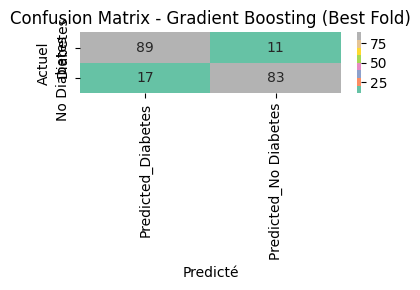

=== XGBoost (Best Fold) ===
Classification Report:
               precision    recall  f1-score   support

    Diabetes       0.85      0.82      0.83       100
 No Diabetes       0.83      0.85      0.84       100

    accuracy                           0.83       200
   macro avg       0.84      0.83      0.83       200
weighted avg       0.84      0.83      0.83       200

Accuracy: 0.835
Precision: 0.8252427184466019
Recall: 0.85
F1 Score: 0.8374384236453202


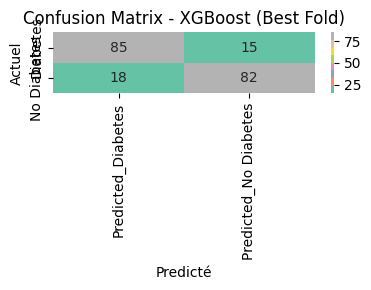

In [57]:
# Display metrics and confusion matrix for the best fold of each model
for model_name, data in best_fold_data.items():
    if data['y_true'] is not None and data['y_pred'] is not None:
        display_metrics_and_confusion(data['y_true'], data['y_pred'], model_name)
    else:
        print(f"Warning: No predictions found for {model_name} to display confusion matrix.")